# 02 — 2026 Era: Year 1 Analysis

Ingests all completed 2026 races, applies the same four metrics as the 2022 baseline, and produces a like-for-like Year 1 comparison.

**Completed rounds as of notebook creation:** Australia (R1), China (R2), Japan (R3)  
**Cancelled:** Bahrain and Saudi Arabia (regional conflict)  
**Next race:** Miami GP (~May 2026)

Metrics:
1. **Constructor points spread** — Gini coefficient and raw P1–P10 gap
2. **Lap time field spread** — P1–P10 fastest lap gap per race
3. **Reliability** — DNF rates by constructor
4. **Qualifying conversion** — grid position vs race finishing position

Then: **Year 1 comparison** — 2026 rounds 1–N vs 2022 rounds 1–N on each metric.

> **Re-runnable:** As Miami and subsequent races are held, re-run this notebook — all sections update automatically.

In [1]:
import sys
import logging
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

# FastF1 tries Ergast as a fallback for driver/results data, but Ergast has
# no 2026 data (maintenance mode). Suppress the resulting WARNING noise —
# lap timing data loads from the F1 live timing system and is unaffected.
logging.getLogger('fastf1').setLevel(logging.ERROR)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.data.fastf1_loader import load_session, get_event_schedule, get_race_control_flags
from src.data.openf1_client import (
    get_sessions as of1_get_sessions,
    get_drivers as of1_get_drivers,
    get_positions as of1_get_positions,
)
from src.utils.era_helper import get_year_within_era
from src.analysis.points_spread import points_gini_by_round, season_end_gini, points_gap_by_round
from src.analysis.reliability import dnf_rate_by_constructor_year, dnf_causes
from src.analysis.lap_time_delta import lap_time_delta_summary, mean_gap_by_season
from src.analysis.quali_race_delta import quali_race_delta, mean_delta_by_constructor

sns.set_theme(style='whitegrid', palette='muted')

SEASON_2026 = 2026
COMPARISON_SEASON = 2022  # Year 1 of Ground Effect Era — like-for-like

# Standard F1 points — used by the OpenF1 fallback when FastF1 results are empty
_F1_POINTS = {1: 25, 2: 18, 3: 15, 4: 12, 5: 10, 6: 8, 7: 6, 8: 4, 9: 2, 10: 1}

print('Libraries loaded.')

Libraries loaded.


## Load 2026 Race Data

Reads the 2026 event schedule and attempts to load every race session.
Cancelled rounds (Bahrain, Saudi Arabia) and future rounds raise exceptions and are skipped gracefully.

The variable `n_rounds` tracks how many rounds loaded — used later to produce the like-for-like 2022 comparison.

In [2]:
import datetime

_SPRINT_FORMATS = {'sprint', 'sprint_shootout', 'sprint_qualifying'}
_DNS_STATUSES = {'Did not start', 'Did not qualify', 'Withdrew'}

# Pre-load OpenF1 race sessions for 2026 — used as fallback if FastF1 results
# are empty (which happens when Ergast has no data for recent seasons).
#
# Sprint weekends have TWO OpenF1 sessions labeled "Race" (Saturday Sprint +
# Sunday Grand Prix). We match by event date rather than sequential index to
# guarantee we always pick the Sunday Grand Prix session.
_of1_all_race_sessions = sorted(
    of1_get_sessions(SEASON_2026, session_type='Race'),
    key=lambda s: s.get('date_start', '')
)
print(f'OpenF1: {len(_of1_all_race_sessions)} sessions labeled "Race" for {SEASON_2026}')


def _find_of1_key(event_date_str: str) -> int | None:
    """Return the OpenF1 session_key for the Grand Prix on a given date.

    For sprint weekends OpenF1 lists both Sprint (Saturday) and GP (Sunday) as
    'Race'. Given the FastF1 EventDate (Sunday), take the latest session within
    1 day — i.e. the Grand Prix, not the Sprint.
    """
    target = datetime.date.fromisoformat(event_date_str[:10])
    candidates = [
        s for s in _of1_all_race_sessions
        if abs((datetime.date.fromisoformat(s['date_start'][:10]) - target).days) <= 1
    ]
    if not candidates:
        return None
    return max(candidates, key=lambda s: s['date_start'])['session_key']


def _results_from_openf1(event_date_str: str, round_num: int, year: int,
                          event_name: str, is_sprint_wknd: bool) -> list[dict]:
    """Build race results from OpenF1 positions data.

    Used when FastF1 session.results is empty due to missing Ergast data.
    Limitations: grid_position defaults to 0; status defaults to 'Finished'.
    """
    session_key = _find_of1_key(event_date_str)
    if session_key is None:
        return []
    drivers = of1_get_drivers(session_key)
    positions = of1_get_positions(session_key)
    if not drivers or not positions:
        return []

    pos_df = pd.DataFrame(positions).sort_values('date')
    final_pos = pos_df.groupby('driver_number').last()['position'].to_dict()
    driver_map = {d['driver_number']: d for d in drivers}

    rows = []
    for drv_num, pos in sorted(final_pos.items(), key=lambda x: x[1]):
        d = driver_map.get(drv_num, {})
        rows.append({
            'season': year,
            'round': round_num,
            'race_name': event_name,
            'is_sprint_weekend': is_sprint_wknd,
            'driver_id': d.get('name_acronym', str(drv_num)),
            'driver_name': d.get('full_name', ''),
            'constructor_id': str(d.get('team_name', '')).lower().replace(' ', '_').replace('-', '_'),
            'constructor_name': d.get('team_name', ''),
            'grid_position': None,  # not available via OpenF1
            'finish_position': int(pos),
            'points': float(_F1_POINTS.get(int(pos), 0)),
            'status': 'Finished',
            'had_sc': False,
            'had_vsc': False,
            'had_red_flag': False,
        })
    return rows


all_results_2026 = []
all_laps_2026 = {}
loaded_rounds_2026 = []
skipped_rounds_2026 = []

schedule_2026 = get_event_schedule(SEASON_2026)
today = datetime.date.today()

race_events_2026 = schedule_2026[
    (schedule_2026['EventFormat'] != 'testing') &
    (pd.to_datetime(schedule_2026['EventDate']).dt.date <= today)
]

print(f'\n2026 completed events to load: {len(race_events_2026)}')

for _, event in race_events_2026.iterrows():
    round_num = int(event['RoundNumber'])
    event_name = event['EventName']
    event_date = str(event['EventDate'])[:10]
    is_sprint_wknd = event['EventFormat'] in _SPRINT_FORMATS

    try:
        session = load_session(SEASON_2026, round_num, 'R')
        results = session.results
        laps = session.laps
        rc_flags = get_race_control_flags(session)

        rows = []
        for _, driver in results.iterrows():
            finish_pos = driver.get('Position')
            grid_pos = driver.get('GridPosition')
            pts = driver.get('Points')
            status = driver.get('Status', '')
            dns = status in _DNS_STATUSES
            rows.append({
                'season': SEASON_2026,
                'round': round_num,
                'race_name': event_name,
                'is_sprint_weekend': is_sprint_wknd,
                'driver_id': driver.get('Abbreviation', ''),
                'driver_name': f"{driver.get('FirstName', '')} {driver.get('LastName', '')}".strip(),
                'constructor_id': str(driver.get('TeamId', '')).lower().replace(' ', '_'),
                'constructor_name': driver.get('TeamName', ''),
                'grid_position': int(grid_pos) if pd.notna(grid_pos) and int(grid_pos) > 0 else None,
                'finish_position': None if dns or not pd.notna(finish_pos) else int(finish_pos),
                'points': float(pts) if pd.notna(pts) else 0.0,
                'status': status,
                'had_sc': rc_flags['had_sc'],
                'had_vsc': rc_flags['had_vsc'],
                'had_red_flag': rc_flags['had_red_flag'],
            })

        if rows:
            all_results_2026.extend(rows)
            all_laps_2026[(SEASON_2026, round_num)] = laps
            loaded_rounds_2026.append((round_num, event_name))
            flags_tag = ''.join([' SC' if rc_flags['had_sc'] else '', ' VSC' if rc_flags['had_vsc'] else '', ' RF' if rc_flags['had_red_flag'] else ''])
            sprint_tag = ' [sprint wknd]' if is_sprint_wknd else ''
            print(f'  R{round_num:02d} {event_name}{sprint_tag}{flags_tag} — {len(rows)} drivers (FastF1)')
        else:
            print(f'  R{round_num:02d} {event_name} — FastF1 results empty, trying OpenF1...')
            of1_rows = _results_from_openf1(event_date, round_num, SEASON_2026, event_name, is_sprint_wknd)
            if of1_rows:
                all_results_2026.extend(of1_rows)
                all_laps_2026[(SEASON_2026, round_num)] = laps
                loaded_rounds_2026.append((round_num, event_name))
                print(f'    OpenF1 fallback OK — {len(of1_rows)} drivers '
                      f'(note: grid_pos=0, DNF status unavailable)')
            else:
                skipped_rounds_2026.append((round_num, event_name, 'No results from FastF1 or OpenF1'))
                print(f'    No results from either source — skipped')

    except Exception as e:
        skipped_rounds_2026.append((round_num, event_name, str(e)))
        print(f'  R{round_num:02d} {event_name} — SKIPPED ({e})')

results_2026 = pd.DataFrame(all_results_2026)
n_rounds = len(loaded_rounds_2026)

print(f'\nLoaded {n_rounds} rounds, {len(results_2026)} entries')
n_sprint = results_2026[results_2026['is_sprint_weekend']]['round'].nunique() if not results_2026.empty else 0
print(f'Sprint weekends: {n_sprint} of {n_rounds} rounds')
if skipped_rounds_2026:
    print(f'Skipped {len(skipped_rounds_2026)} (cancelled — no data):')
    for r, name, _ in skipped_rounds_2026:
        print(f'  R{r:02d} {name}')

rc_summary = results_2026.drop_duplicates(['season', 'round'])[['round', 'had_sc', 'had_vsc', 'had_red_flag']]
print(f'Race control events across {len(rc_summary)} races:')
print(f'  Safety car:         {rc_summary["had_sc"].sum()} races')
print(f'  Virtual safety car: {rc_summary["had_vsc"].sum()} races')
print(f'  Red flag:           {rc_summary["had_red_flag"].sum()} races')

OpenF1: 30 sessions labeled "Race" for 2026


core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...



2026 completed events to load: 3


core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '16', '44', '1', '3', '87', '41', '5', '10', '31', '23', '30', '43', '55', '11', '18', '14', '77', '6', '81', '27']
core           INFO 	Loading data for Chinese Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req    

  R01 Australian Grand Prix — 22 drivers (FastF1)


core        WARNING 	Driver 12 completed the race distance 00:00.022000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['12', '63', '44', '16', '87', '10', '30', '6', '55', '43', '27', '41', '77', '31', '11', '3', '14', '18', '81', '1', '5', '23']
core           INFO 	Loading data for Japanese Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for 

  R02 Chinese Grand Prix [sprint wknd] SC — 22 drivers (FastF1)


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['12', '81', '16', '63', '1', '44', '10', '3', '30', '31', '27', '6', '5', '41', '55', '43', '11', '14', '77', '23', '18', '87']


  R03 Japanese Grand Prix SC — 22 drivers (FastF1)

Loaded 3 rounds, 66 entries
Sprint weekends: 1 of 3 rounds
Race control events across 3 races:
  Safety car:         2 races
  Virtual safety car: 0 races
  Red flag:           0 races


In [3]:
# Normalise 2026 constructor IDs.
# Sauber rebranded to Audi for 2026.
# Cadillac is a new 11th constructor - no alias needed.
_CONSTRUCTOR_ALIASES_2026 = {
    'sauber':      'audi',
    'kick_sauber': 'audi',
}
_CONSTRUCTOR_DISPLAY_2026 = {
    'audi': 'Audi (Sauber)',
}

results_2026['constructor_id'] = results_2026['constructor_id'].replace(_CONSTRUCTOR_ALIASES_2026)
results_2026['constructor_name'] = (
    results_2026['constructor_id']
    .map(_CONSTRUCTOR_DISPLAY_2026)
    .fillna(results_2026['constructor_name'])
)

print('2026 constructor normalisation applied.')
print(results_2026[['constructor_id', 'constructor_name']].drop_duplicates().sort_values('constructor_id').to_string(index=False))
cadillac = results_2026[results_2026['constructor_id'].str.contains('cadillac', case=False, na=False)]
if not cadillac.empty:
    print('Cadillac: ' + str(len(cadillac)) + ' entries (new 11th constructor, 2026)')


2026 constructor normalisation applied.
constructor_id constructor_name
        alpine           Alpine
  aston_martin     Aston Martin
          audi    Audi (Sauber)
      cadillac         Cadillac
       ferrari          Ferrari
          haas     Haas F1 Team
       mclaren          McLaren
      mercedes         Mercedes
            rb     Racing Bulls
      red_bull  Red Bull Racing
      williams         Williams
Cadillac: 6 entries (new 11th constructor, 2026)


## 1. Constructor Points Spread (2026)

Gini coefficient across all loaded 2026 rounds. With only a handful of rounds, the trajectory is early — note this when interpreting.

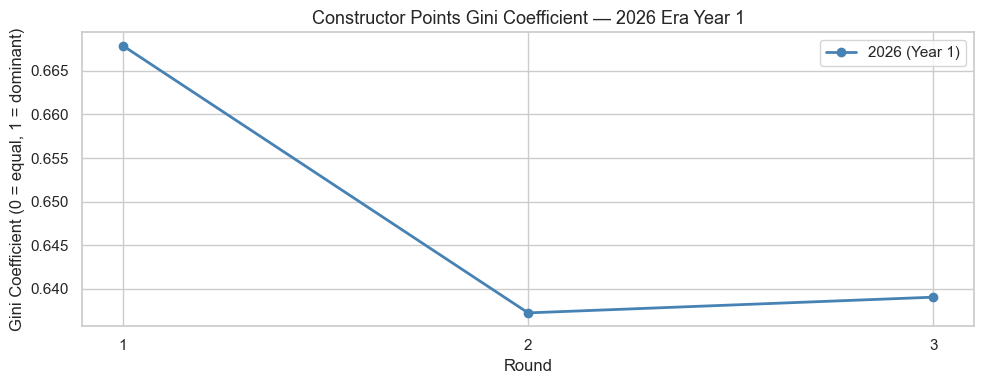


Constructor standings after each round:

After R01 Australian Grand Prix:
constructor_id  points
      mercedes    43.0
       ferrari    27.0
       mclaren    10.0
      red_bull     8.0
          haas     6.0
            rb     4.0
          audi     2.0
        alpine     1.0
  aston_martin     0.0
      cadillac     0.0
      williams     0.0

After R02 Chinese Grand Prix:
constructor_id  points
      mercedes    86.0
       ferrari    54.0
          haas    16.0
      red_bull    12.0
            rb    10.0
        alpine    10.0
       mclaren    10.0
      williams     2.0
          audi     2.0
  aston_martin     0.0
      cadillac     0.0

After R03 Japanese Grand Prix:
constructor_id  points
      mercedes   123.0
       ferrari    77.0
       mclaren    38.0
          haas    17.0
      red_bull    16.0
        alpine    16.0
            rb    12.0
      williams     2.0
          audi     2.0
  aston_martin     0.0
      cadillac     0.0


In [4]:
# Build cumulative constructor standings by round
season_df = results_2026.sort_values('round')
cumulative = (
    season_df
    .groupby(['constructor_id', 'round'])['points']
    .sum()
    .groupby('constructor_id')
    .cumsum()
    .reset_index()
)
cumulative['season'] = SEASON_2026
cumulative.columns = ['constructor_id', 'round', 'points', 'season']

standings_2026 = cumulative

gini_2026 = points_gini_by_round(standings_2026)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(gini_2026['round'], gini_2026['gini'], marker='o', linewidth=2, color='steelblue', label='2026 (Year 1)')
ax.set_title('Constructor Points Gini Coefficient — 2026 Era Year 1', fontsize=13)
ax.set_xlabel('Round')
ax.set_ylabel('Gini Coefficient (0 = equal, 1 = dominant)')
ax.set_xticks(gini_2026['round'])
ax.legend()
plt.tight_layout()
plt.show()

print('\nConstructor standings after each round:')
for rnd, name in loaded_rounds_2026:
    rnd_standings = (
        standings_2026[standings_2026['round'] == rnd]
        .sort_values('points', ascending=False)
        [['constructor_id', 'points']]
    )
    print(f'\nAfter R{rnd:02d} {name}:')
    print(rnd_standings.to_string(index=False))

## 2. Lap Time Field Spread (2026)

P1–P10 fastest lap gap per race. Each data point is one race — the trend line shows trajectory across the season so far.

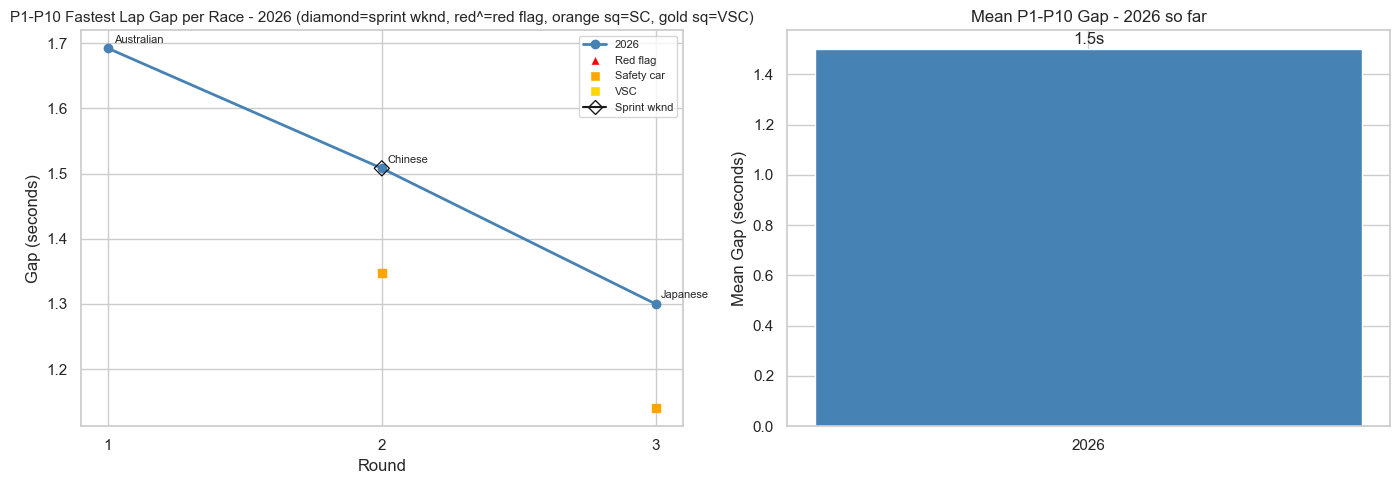

P1-P10 gap by race:
 round  is_sprint_weekend  had_sc  had_vsc  had_red_flag  p1_lap_s  p10_lap_s  gap_s
     1              False   False    False         False    82.091     83.783  1.692
     2               True    True    False         False    95.275     96.783  1.508
     3              False    True    False         False    92.432     93.732  1.300
Conventional weekends mean gap: 1.5s
Sprint weekends mean gap:       1.51s


In [5]:
delta_2026 = lap_time_delta_summary(all_laps_2026)
mean_2026 = mean_gap_by_season(delta_2026)

# Join sprint weekend and race control flags
race_meta_2026 = results_2026[['round', 'is_sprint_weekend', 'had_sc', 'had_vsc', 'had_red_flag']].drop_duplicates()
delta_2026 = delta_2026.merge(race_meta_2026, on='round', how='left')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(delta_2026['round'], delta_2026['gap_s'], marker='o', linewidth=2, color='steelblue', label='2026')
for _, row in delta_2026.iterrows():
    race_rows = results_2026[results_2026['round'] == row['round']]
    race_name = race_rows['race_name'].iloc[0] if not race_rows.empty else ''
    axes[0].annotate(race_name.replace(' Grand Prix', ''), (row['round'], row['gap_s']),
                     textcoords='offset points', xytext=(4, 4), fontsize=8)

# Diamond overlay for sprint weekends
sprint_rows = delta_2026[delta_2026['is_sprint_weekend'] == True]
if not sprint_rows.empty:
    axes[0].scatter(sprint_rows['round'], sprint_rows['gap_s'],
                    marker='D', s=60, zorder=5, edgecolors='black', linewidths=0.8, facecolors='none')

# Race control markers below the gap line
offset = 0.08
rf_rows  = delta_2026[delta_2026['had_red_flag'] == True]
sc_rows  = delta_2026[delta_2026['had_sc'] == True]
vsc_rows = delta_2026[delta_2026['had_vsc'] == True]
if not rf_rows.empty:
    axes[0].scatter(rf_rows['round'], rf_rows['gap_s'] - offset, marker='^', s=50, color='red', zorder=4)
if not sc_rows.empty:
    axes[0].scatter(sc_rows['round'], sc_rows['gap_s'] - offset * 2, marker='s', s=40, color='orange', zorder=4)
if not vsc_rows.empty:
    axes[0].scatter(vsc_rows['round'], vsc_rows['gap_s'] - offset * 3, marker='s', s=40, color='gold', zorder=4)

from matplotlib.lines import Line2D
rc_handles = [
    Line2D([0], [0], marker='^', color='w', markerfacecolor='red', markersize=7, label='Red flag'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='orange', markersize=7, label='Safety car'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gold', markersize=7, label='VSC'),
    Line2D([0], [0], marker='D', color='k', markerfacecolor='none', markersize=7, label='Sprint wknd'),
]
axes[0].legend(handles=axes[0].get_legend_handles_labels()[0] + rc_handles, fontsize=8)
axes[0].set_title('P1-P10 Fastest Lap Gap per Race - 2026 (diamond=sprint wknd, red^=red flag, orange sq=SC, gold sq=VSC)', fontsize=11)
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Gap (seconds)')
axes[0].set_xticks(delta_2026['round'])

if not mean_2026.empty:
    axes[1].bar(['2026'], mean_2026['mean_gap_s'], color='steelblue', width=0.4)
    axes[1].set_title('Mean P1-P10 Gap - 2026 so far', fontsize=12)
    axes[1].set_ylabel('Mean Gap (seconds)')
    axes[1].text(0, mean_2026['mean_gap_s'].iloc[0] + 0.02, str(round(mean_2026['mean_gap_s'].iloc[0], 2)) + 's', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

print('P1-P10 gap by race:')
print(delta_2026[['round', 'is_sprint_weekend', 'had_sc', 'had_vsc', 'had_red_flag', 'p1_lap_s', 'p10_lap_s', 'gap_s']].to_string(index=False))

if not sprint_rows.empty:
    conv_mean = delta_2026[~delta_2026['is_sprint_weekend']]['gap_s'].mean()
    sprt_mean = delta_2026[delta_2026['is_sprint_weekend']]['gap_s'].mean()
    print('Conventional weekends mean gap: ' + str(round(conv_mean, 2)) + 's')
    print('Sprint weekends mean gap:       ' + str(round(sprt_mean, 2)) + 's')


## 3. Reliability — DNF Rates (2026)

DNF rate = retirements as a percentage of race starts by constructor.
Small sample warning: three races means a single DNF equals ~33% rate — treat as directional, not conclusive.

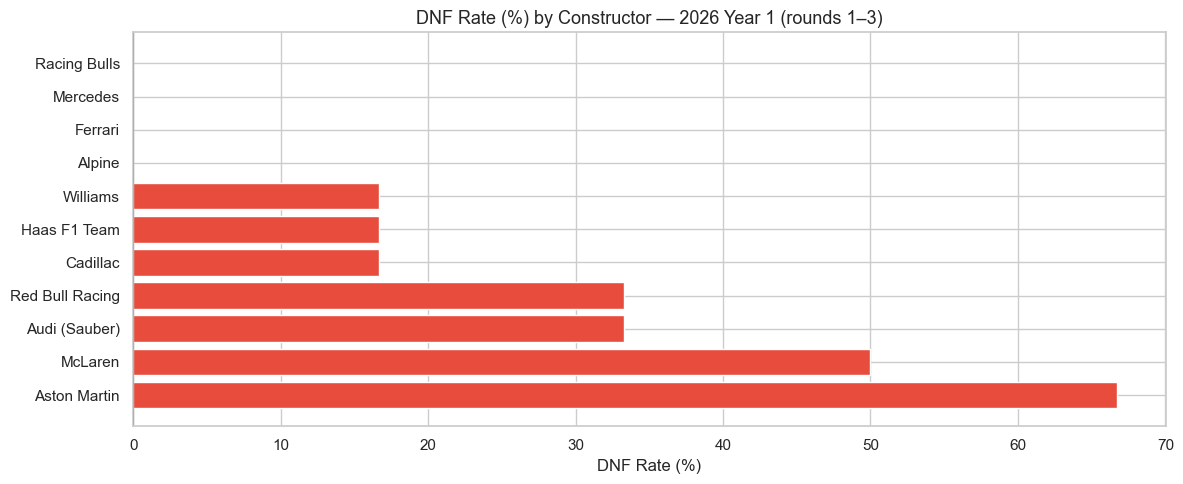


DNF summary:
constructor_name  starts  dnfs  dnf_rate_pct
    Aston Martin       6     4          66.7
         McLaren       6     3          50.0
   Audi (Sauber)       6     2          33.3
 Red Bull Racing       6     2          33.3
        Cadillac       6     1          16.7
    Haas F1 Team       6     1          16.7
        Williams       6     1          16.7
          Alpine       6     0           0.0
         Ferrari       6     0           0.0
        Mercedes       6     0           0.0
    Racing Bulls       6     0           0.0

DNF causes:
       status  count
      Retired      8
Did not start      6


In [6]:
dnf_df_2026 = dnf_rate_by_constructor_year(results_2026)

fig, ax = plt.subplots(figsize=(12, 5))
colours = ['#e74c3c' if r > 0 else '#2ecc71' for r in dnf_df_2026['dnf_rate_pct']]
ax.barh(dnf_df_2026['constructor_name'], dnf_df_2026['dnf_rate_pct'], color=colours)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('DNF Rate (%) by Constructor — 2026 Year 1 (rounds 1–' + str(n_rounds) + ')', fontsize=13)
ax.set_xlabel('DNF Rate (%)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print('\nDNF summary:')
print(dnf_df_2026[['constructor_name', 'starts', 'dnfs', 'dnf_rate_pct']].to_string(index=False))

causes_2026 = dnf_causes(results_2026)
if not causes_2026.empty:
    print('\nDNF causes:')
    print(causes_2026.to_string(index=False))

## 4. Qualifying → Race Conversion (2026)

Mean position delta (grid − finish) by constructor.
Positive = gained places on average. DNFs excluded from average, counted separately.

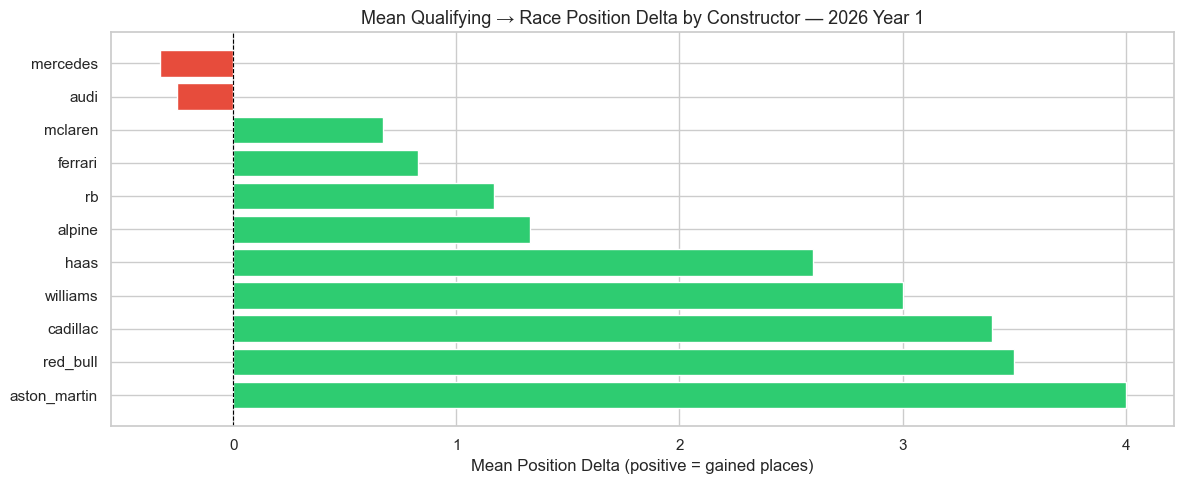


Constructor quali→race conversion:
constructor_id  races  mean_delta  dnf_count
  aston_martin      2        4.00          4
      red_bull      4        3.50          2
      cadillac      5        3.40          1
      williams      5        3.00          1
          haas      5        2.60          1
        alpine      6        1.33          0
            rb      6        1.17          0
       ferrari      6        0.83          0
       mclaren      3        0.67          3
          audi      4       -0.25          2
      mercedes      6       -0.33          0


In [7]:
delta_results_2026 = quali_race_delta(results_2026)
constructor_conv_2026 = mean_delta_by_constructor(delta_results_2026)

fig, ax = plt.subplots(figsize=(12, 5))
colours = ['#2ecc71' if d >= 0 else '#e74c3c' for d in constructor_conv_2026['mean_delta']]
ax.barh(constructor_conv_2026['constructor_id'], constructor_conv_2026['mean_delta'], color=colours)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Mean Qualifying → Race Position Delta by Constructor — 2026 Year 1', fontsize=13)
ax.set_xlabel('Mean Position Delta (positive = gained places)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print('\nConstructor quali→race conversion:')
print(constructor_conv_2026[['constructor_id', 'races', 'mean_delta', 'dnf_count']].to_string(index=False))

---

## Year 1 Comparison: 2026 vs 2022

Like-for-like comparison: **2022 rounds 1–N vs 2026 rounds 1–N**, where N = number of 2026 rounds loaded.

This anchors the comparison to the same point in the season — both series are at the same maturity level.

> **2022 note:** The 2022 season opened with Bahrain (R1), Saudi Arabia (R2), Australia (R3) — a different circuit order to 2026 (Australia, China, Japan). The round-count comparison is valid for convergence metrics but circuit mix will differ.

In [8]:
# Load 2022 rounds 1 through n_rounds for the like-for-like comparison
all_results_2022_cmp = []
all_laps_2022_cmp = {}

_SPRINT_FORMATS_CMP = {'sprint', 'sprint_shootout', 'sprint_qualifying'}
_DNS_STATUSES_CMP = {'Did not start', 'Did not qualify', 'Withdrew'}

schedule_2022 = get_event_schedule(COMPARISON_SEASON)
race_events_2022 = schedule_2022[
    (schedule_2022['EventFormat'] != 'testing') &
    (schedule_2022['RoundNumber'] <= n_rounds)
]

print(f'Loading 2022 rounds 1-{n_rounds} for comparison...')
for _, event in race_events_2022.iterrows():
    round_num = int(event['RoundNumber'])
    event_name = event['EventName']
    is_sprint_wknd = event['EventFormat'] in _SPRINT_FORMATS_CMP
    try:
        session = load_session(COMPARISON_SEASON, round_num, 'R')
        results = session.results
        laps = session.laps
        rc_flags = get_race_control_flags(session)
        for _, driver in results.iterrows():
            finish_pos = driver.get('Position')
            grid_pos = driver.get('GridPosition')
            pts = driver.get('Points')
            status = driver.get('Status', '')
            dns = status in _DNS_STATUSES_CMP
            first = driver.get('FirstName', '')
            last = driver.get('LastName', '')
            all_results_2022_cmp.append({
                'season': COMPARISON_SEASON,
                'round': round_num,
                'race_name': event_name,
                'is_sprint_weekend': is_sprint_wknd,
                'driver_id': driver.get('Abbreviation', ''),
                'driver_name': f'{first} {last}'.strip(),
                'constructor_id': str(driver.get('TeamId', '')).lower().replace(' ', '_'),
                'constructor_name': driver.get('TeamName', ''),
                'grid_position': int(grid_pos) if pd.notna(grid_pos) and int(grid_pos) > 0 else None,
                'finish_position': None if dns or not pd.notna(finish_pos) else int(finish_pos),
                'points': float(pts) if pd.notna(pts) else 0.0,
                'status': status,
                'had_sc': rc_flags['had_sc'],
                'had_vsc': rc_flags['had_vsc'],
                'had_red_flag': rc_flags['had_red_flag'],
            })
        all_laps_2022_cmp[(COMPARISON_SEASON, round_num)] = laps
        sprint_tag = ' [sprint wknd]' if is_sprint_wknd else ''
        print(f'  R{round_num:02d} {event_name}{sprint_tag} - {len(results)} drivers')
    except Exception as e:
        print(f'  R{round_num:02d} {event_name} - SKIPPED ({e})')

results_2022_cmp = pd.DataFrame(all_results_2022_cmp)
print(f'2022 comparison: {len(results_2022_cmp)} entries across {len(race_events_2022)} rounds')


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


Loading 2022 rounds 1-3 for comparison...


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 16 completed the race distance 00:00.050000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '55', '44', '63', '20', '77', '31', '22', '14', '24', '47', '18', '23', '3', '4', '6', '27', '11', '1', '10']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info

  R01 Bahrain Grand Prix - 20 drivers


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 22
core        WARNING 	No lap data for driver 47
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 22)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 47)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '16', '55', '11', '63', '31', '4', '10', '20', '44', '24', 

  R02 Saudi Arabian Grand Prix - 20 drivers


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 16 completed the race distance 00:00.140000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '11', '63', '44', '4', '3', '31', '77', '10', '23', '24', '18', '47', '20', '22', '6', '14', '1', '5', '55']


  R03 Australian Grand Prix - 20 drivers
2022 comparison: 60 entries across 3 rounds


In [9]:
# Normalise 2022 comparison constructor IDs — same rebrands as the full baseline.
_CONSTRUCTOR_ALIASES_CMP = {
    'alphatauri': 'rb',
    'alfa':       'sauber',
}
_CONSTRUCTOR_DISPLAY_CMP = {
    'rb':     'Racing Bulls / AlphaTauri',
    'sauber': 'Sauber / Alfa Romeo',
}

results_2022_cmp['constructor_id'] = results_2022_cmp['constructor_id'].replace(_CONSTRUCTOR_ALIASES_CMP)
results_2022_cmp['constructor_name'] = (
    results_2022_cmp['constructor_id']
    .map(_CONSTRUCTOR_DISPLAY_CMP)
    .fillna(results_2022_cmp['constructor_name'])
)
print('2022 comparison constructor normalisation applied.')


2022 comparison constructor normalisation applied.


In [10]:
# Build cumulative standings for 2022 comparison slice
s22 = results_2022_cmp.sort_values('round')
cum22 = (
    s22.groupby(['constructor_id', 'round'])['points']
    .sum()
    .groupby('constructor_id')
    .cumsum()
    .reset_index()
)
cum22['season'] = COMPARISON_SEASON
cum22.columns = ['constructor_id', 'round', 'points', 'season']
standings_2022_cmp = cum22

gini_2022_cmp = points_gini_by_round(standings_2022_cmp)
gini_2026_cmp = points_gini_by_round(standings_2026)

delta_2022_cmp = lap_time_delta_summary(all_laps_2022_cmp)
mean_2022_cmp = mean_gap_by_season(delta_2022_cmp)

dnf_2022_cmp = dnf_rate_by_constructor_year(results_2022_cmp)
dnf_2026_cmp = dnf_rate_by_constructor_year(results_2026)

qrd_2022_cmp = mean_delta_by_constructor(quali_race_delta(results_2022_cmp))
qrd_2026_cmp = mean_delta_by_constructor(quali_race_delta(results_2026))

print('Comparison data built.')

Comparison data built.


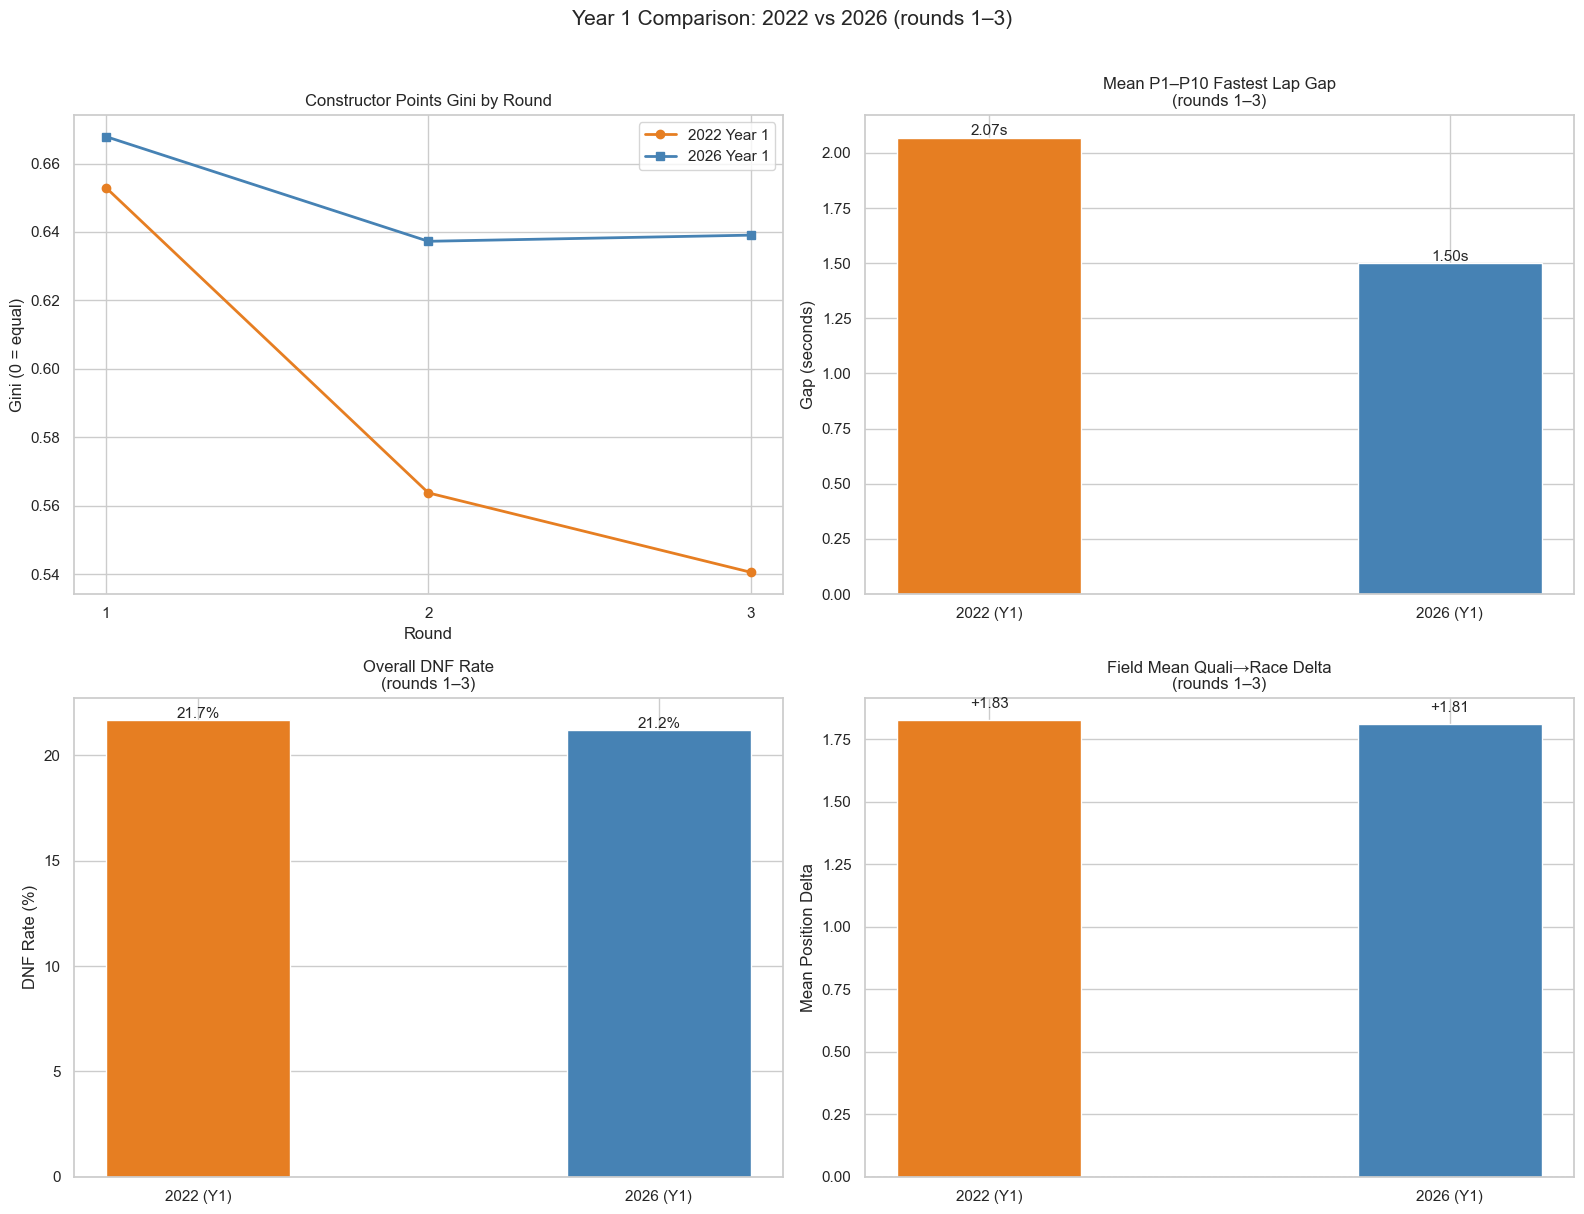

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Year 1 Comparison: 2022 vs 2026 (rounds 1–{n_rounds})', fontsize=15, y=1.01)

# --- 1. Gini by round ---
ax = axes[0, 0]
ax.plot(gini_2022_cmp['round'], gini_2022_cmp['gini'],
        marker='o', linewidth=2, color='#e67e22', label='2022 Year 1')
ax.plot(gini_2026_cmp['round'], gini_2026_cmp['gini'],
        marker='s', linewidth=2, color='steelblue', label='2026 Year 1')
ax.set_title('Constructor Points Gini by Round')
ax.set_xlabel('Round')
ax.set_ylabel('Gini (0 = equal)')
ax.set_xticks(range(1, n_rounds + 1))
ax.legend()

# --- 2. Mean P1-P10 lap gap ---
ax = axes[0, 1]
labels = ['2022 (Y1)', '2026 (Y1)']
values_22 = mean_2022_cmp['mean_gap_s'].values if not mean_2022_cmp.empty else [0]
values_26 = mean_2026['mean_gap_s'].values if not mean_2026.empty else [0]
bar_vals = [values_22[0], values_26[0]]
bar_colours = ['#e67e22', 'steelblue']
bars = ax.bar(labels, bar_vals, color=bar_colours, width=0.4)
for bar, val in zip(bars, bar_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
            f'{val:.2f}s', ha='center', fontsize=11)
ax.set_title(f'Mean P1–P10 Fastest Lap Gap\n(rounds 1–{n_rounds})')
ax.set_ylabel('Gap (seconds)')

# --- 3. DNF rate comparison ---
ax = axes[1, 0]
overall_dnf_22 = dnf_2022_cmp['dnfs'].sum() / dnf_2022_cmp['starts'].sum() * 100 if dnf_2022_cmp['starts'].sum() > 0 else 0
overall_dnf_26 = dnf_2026_cmp['dnfs'].sum() / dnf_2026_cmp['starts'].sum() * 100 if dnf_2026_cmp['starts'].sum() > 0 else 0
bars = ax.bar(labels, [overall_dnf_22, overall_dnf_26], color=bar_colours, width=0.4)
for bar, val in zip(bars, [overall_dnf_22, overall_dnf_26]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.1,
            f'{val:.1f}%', ha='center', fontsize=11)
ax.set_title(f'Overall DNF Rate\n(rounds 1–{n_rounds})')
ax.set_ylabel('DNF Rate (%)')

# --- 4. Quali->race delta (field mean) ---
ax = axes[1, 1]
mean_qrd_22 = qrd_2022_cmp['mean_delta'].mean() if not qrd_2022_cmp.empty else 0
mean_qrd_26 = qrd_2026_cmp['mean_delta'].mean() if not qrd_2026_cmp.empty else 0
qrd_colours = ['#2ecc71' if v >= 0 else '#e74c3c' for v in [mean_qrd_22, mean_qrd_26]]
bars = ax.bar(labels, [mean_qrd_22, mean_qrd_26], color=bar_colours, width=0.4)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars, [mean_qrd_22, mean_qrd_26]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + (0.05 if val >= 0 else -0.15),
            f'{val:+.2f}', ha='center', fontsize=11)
ax.set_title(f'Field Mean Quali→Race Delta\n(rounds 1–{n_rounds})')
ax.set_ylabel('Mean Position Delta')

plt.tight_layout()
plt.show()

In [12]:
# Gini at each shared round — tabular comparison
merged_gini = gini_2022_cmp[['round', 'gini']].rename(columns={'gini': 'gini_2022'}).merge(
    gini_2026_cmp[['round', 'gini']].rename(columns={'gini': 'gini_2026'}),
    on='round', how='outer'
).sort_values('round')
merged_gini['delta'] = merged_gini['gini_2026'] - merged_gini['gini_2022']

print(f'Gini comparison (rounds 1–{n_rounds}):')
print(merged_gini.to_string(index=False))

print(f'\nLap time gap comparison:')
print(f'  2022 Y1 mean P1–P10 gap: {values_22[0]:.3f}s')
print(f'  2026 Y1 mean P1–P10 gap: {values_26[0]:.3f}s')
print(f'  Delta: {values_26[0] - values_22[0]:+.3f}s')

print(f'\nDNF rate comparison:')
print(f'  2022 Y1: {overall_dnf_22:.1f}%')
print(f'  2026 Y1: {overall_dnf_26:.1f}%')
print(f'  Delta: {overall_dnf_26 - overall_dnf_22:+.1f}pp')

Gini comparison (rounds 1–3):
 round  gini_2022  gini_2026    delta
     1   0.652941   0.667867 0.014926
     2   0.563725   0.637264 0.073538
     3   0.540523   0.639064 0.098541

Lap time gap comparison:
  2022 Y1 mean P1–P10 gap: 2.069s
  2026 Y1 mean P1–P10 gap: 1.500s
  Delta: -0.569s

DNF rate comparison:
  2022 Y1: 21.7%
  2026 Y1: 21.2%
  Delta: -0.5pp


## Driver Continuity — Who Crossed the Era Boundary?

Identifies drivers who competed in both the 2022 Ground Effect Era opening and 2026 Era Year 1.
These drivers provide the cleanest like-for-like driver performance comparison across the regulation reset.

In [13]:
# Use the full 2022 season from the comparison data (already cached)
drivers_2022 = set(results_2022_cmp['driver_id'].unique())
drivers_2026 = set(results_2026['driver_id'].unique())

both_eras = sorted(drivers_2022 & drivers_2026)
only_2022 = sorted(drivers_2022 - drivers_2026)
only_2026 = sorted(drivers_2026 - drivers_2022)

print(f'Drivers in BOTH 2022 and 2026 ({len(both_eras)}):')
for d in both_eras:
    name_22 = results_2022_cmp[results_2022_cmp['driver_id'] == d]['driver_name'].iloc[0]
    team_22 = results_2022_cmp[results_2022_cmp['driver_id'] == d]['constructor_name'].iloc[0]
    team_26 = results_2026[results_2026['driver_id'] == d]['constructor_name'].iloc[0]
    team_change = f'{team_22} → {team_26}' if team_22 != team_26 else team_22
    print(f'  {d:<6} {name_22:<25} {team_change}')

print(f'\nDrivers only in 2022 Y1 sample (rookies since or departed): {len(only_2022)}')
print(f'  {", ".join(only_2022)}')

print(f'\nDrivers only in 2026 (new to F1 or returning after absence): {len(only_2026)}')
print(f'  {", ".join(only_2026)}')

Drivers in BOTH 2022 and 2026 (14):
  ALB    Alexander Albon           Williams
  ALO    Fernando Alonso           Alpine → Aston Martin
  BOT    Valtteri Bottas           Sauber / Alfa Romeo → Cadillac
  GAS    Pierre Gasly              Racing Bulls / AlphaTauri → Alpine
  HAM    Lewis Hamilton            Mercedes → Ferrari
  HUL    Nico Hulkenberg           Aston Martin → Audi (Sauber)
  LEC    Charles Leclerc           Ferrari
  NOR    Lando Norris              McLaren
  OCO    Esteban Ocon              Alpine → Haas F1 Team
  PER    Sergio Perez              Red Bull Racing → Cadillac
  RUS    George Russell            Mercedes
  SAI    Carlos Sainz              Ferrari → Williams
  STR    Lance Stroll              Aston Martin
  VER    Max Verstappen            Red Bull Racing

Drivers only in 2022 Y1 sample (rookies since or departed): 7
  LAT, MAG, MSC, RIC, TSU, VET, ZHO

Drivers only in 2026 (new to F1 or returning after absence): 8
  ANT, BEA, BOR, COL, HAD, LAW, LIN, PIA


## Findings and Next Steps

Record observations as you run the notebook:

| Metric | 2022 Y1 (R1–3) | 2026 Y1 (R1–3) | Observation |
|---|---|---|---|
| Gini (after R3) | 0.541 | 0.639 | 2026 more unequal — early Mercedes dominance concentrating points. Gap widening round-on-round suggests dominance increasing, not a one-off |
| Mean P1–P10 gap | 2.069s | 1.500s | Field 0.57s closer on pace in 2026 — strongest convergence signal, but circuit mix differs (2022: Bahrain/Saudi/Australia vs 2026: Australia/China/Japan). Australia is the only shared circuit — treat with caution until more rounds available |
| DNF rate | 21.7% | 21.2% | Essentially identical — reliability similar at the same stage of each era |
| Field mean quali→race | +1.83 | +1.81 | No meaningful difference — conversion patterns consistent across the regulation reset |
| Sprint vs conventional gap | n/a | 1.50s vs 1.51s (n=1 sprint) | Too early to draw conclusions — revisit after Miami |

**Next:** Re-run after Miami GP to extend the 2026 picture. The comparison section auto-adjusts to however many rounds have been loaded.

**v0.4.0 prep:** Once 6+ rounds are available, add sector time breakdown and intra-team driver comparison — see `BACKLOG.md`.